# Smart Energy AI
## Household Appliance Energy Consumption Prediction

**Dataset:** [Appliances Energy Prediction Data Set (Kaggle)](https://www.kaggle.com/datasets/sohommajumder21/appliances-energy-prediction-data-set)

This notebook builds a machine learning system that predicts household appliance
energy consumption from indoor environmental conditions, outdoor weather, and time
information. It covers the complete workflow: data cleaning, exploratory data
analysis, preprocessing, feature engineering, model building, evaluation,
optimization, and deployment preparation.

# 1. Introduction

## 1.1 Project Objective

The goal of **Smart Energy AI** is to build a machine learning system that predicts
household appliance energy consumption (in Watt-hours) using time information,
indoor environmental conditions, and outdoor weather conditions.

The project also analyzes which factors most affect energy consumption and when
consumption tends to be highest.

## 1.2 Problem Statement

Users typically do not know how much electricity their appliances will consume or
when consumption is likely to increase. Appliance energy usage is affected by many
factors, including the time of day, day of week, indoor temperature and humidity,
lighting usage, and outdoor weather.

The main task is a **regression problem**: predict the continuous target variable
`Appliances` (Wh) from these input features.

## 1.3 Project Goal and Importance

Being able to anticipate expected appliance energy consumption helps users:

- Understand their expected electricity usage.
- Identify periods of unusually high consumption.
- Make informed decisions about energy-saving behavior.

This directly supports the Smart Energy AI idea of turning raw sensor and weather
data into actionable predictions about household energy use.

# 2. Dataset Selection

## 2.1 Dataset Source

The dataset used in this project is the **Appliances Energy Prediction Data Set**,
available on Kaggle:

<https://www.kaggle.com/datasets/sohommajumder21/appliances-energy-prediction-data-set>

It contains real household measurements collected every 10 minutes over
approximately 4.5 months, combined with weather data from the nearest airport
weather station (Chievres, Belgium).

In [84]:
# Data manipulation
import os
from pathlib import Path
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, roc_curve)

# Saving the final model
import joblib

# Display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [36]:
# Load the raw dataset
DATA_PATH = "../data/raw/energydata_complete.csv"

# Small, simple fallback in case the notebook is run from a different folder
if not os.path.exists(DATA_PATH):
    DATA_PATH = "data/raw/energydata_complete.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")


Dataset loaded successfully.


## 2.2 Dataset Dimensions

The project requires at least 10,000 samples and 12 features.

In [37]:
# Run this step and inspect the output below
rows, columns = df.shape
print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 19735
Number of columns: 29


### Insight

The dataset contains 19,735 observations and 29 columns, which satisfies the
project requirement of at least 10,000 samples and 12 features.

In [38]:
# Run this step and inspect the output below
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,11-01-2016 17:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,11-01-2016 17:10,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,11-01-2016 17:20,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,11-01-2016 17:30,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,11-01-2016 17:40,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## 2.3 Target Variable

The target variable is `Appliances`, representing household appliance energy
consumption in Watt-hours (Wh). Since this variable is continuous, the main task
is **regression**.

In [39]:
# Run this step and inspect the output below
print("Target variable:", "Appliances")
print("Target data type:", df["Appliances"].dtype)
print("Target range: {} to {} Wh".format(df["Appliances"].min(), df["Appliances"].max()))

Target variable: Appliances
Target data type: int64
Target range: 10 to 1080 Wh


## 2.4 Feature Description

| Feature | Description | Unit |
|---|---|---|
| `date` | Date and time of the observation | Timestamp |
| `Appliances` | Household appliance energy consumption (target) | Wh |
| `lights` | Energy used by lighting fixtures | Wh |
| `T1`-`T9` | Indoor temperature in 9 rooms of the house | °C |
| `RH_1`-`RH_9` | Indoor humidity in 9 rooms of the house | % |
| `T_out` | Outdoor temperature (Chievres weather station) | °C |
| `Press_mm_hg` | Atmospheric pressure | mm Hg |
| `RH_out` | Outdoor humidity | % |
| `Windspeed` | Outdoor wind speed | m/s |
| `Visibility` | Outdoor visibility | km |
| `Tdewpoint` | Outdoor dew point temperature | °C |
| `rv1`, `rv2` | Random variables (noise, included in the original dataset) | Nondimensional |

There are no categorical features — every input feature is numerical or a
timestamp.

# 3. Data Cleaning

We check the dataset for duplicates, missing values, invalid dates, and invalid
numerical values, then detect potential outliers with the IQR method.

## 3.1 Duplicate Records

In [40]:
# Run this step and inspect the output below
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


## 3.2 Missing Values

In [41]:
# Run this step and inspect the output below
missing = df.isnull().sum()
print("Total missing values:", missing.sum())

Total missing values: 0


### Insight

There are no duplicate rows and no missing values in the raw dataset, so no
imputation or row removal is required at this stage.

## 3.3 Date Validation and Conversion

In [42]:
# Run this step and inspect the output below
print("Date dtype before conversion:", df["date"].dtype)

df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Date dtype after conversion:", df["date"].dtype)
print("Invalid dates after conversion:", df["date"].isna().sum())

Date dtype before conversion: str
Date dtype after conversion: datetime64[us]
Invalid dates after conversion: 12637


## 3.4 Invalid Numerical Values

In [43]:
# Run this step and inspect the output below
invalid_checks = {
    "Negative Appliances": (df["Appliances"] < 0).sum(),
    "Negative Lights": (df["lights"] < 0).sum(),
    "Negative Windspeed": (df["Windspeed"] < 0).sum(),
    "Negative Visibility": (df["Visibility"] < 0).sum(),
    "Non-positive Pressure": (df["Press_mm_hg"] <= 0).sum(),
}
rh_columns = [c for c in df.columns if c.startswith("RH_")]
for c in rh_columns:
    invalid_checks[f"Invalid {c}"] = ((df[c] < 0) | (df[c] > 100)).sum()

pd.Series(invalid_checks)

Negative Appliances      0
Negative Lights          0
Negative Windspeed       0
Negative Visibility      0
Non-positive Pressure    0
Invalid RH_1             0
Invalid RH_2             0
Invalid RH_3             0
Invalid RH_4             0
Invalid RH_5             0
Invalid RH_6             0
Invalid RH_7             0
Invalid RH_8             0
Invalid RH_9             0
Invalid RH_out           0
dtype: int64

### Insight

No physically invalid values were found (no negative energy, humidity outside
0-100%, negative wind speed/visibility, or non-positive pressure). The dataset
does not require corrections at this stage.

## 3.5 Outlier Detection (IQR method)

In [44]:
# Run this step and inspect the output below
numeric_columns = df.select_dtypes(include=np.number).columns

outlier_counts = {}
for column in numeric_columns:
    Q1, Q3 = df[column].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outlier_counts[column] = ((df[column] < lower) | (df[column] > upper)).sum()

outlier_summary = pd.Series(outlier_counts).sort_values(ascending=False)
outlier_pct = (outlier_summary / len(df) * 100).round(2)

pd.DataFrame({"Outliers": outlier_summary, "Outlier %": outlier_pct}).head(10)

,Outliers,Outlier %
lights,4483,22.72
Visibility,2522,12.78
Appliances,2138,10.83
RH_5,1330,6.74
T2,546,2.77
T1,515,2.61
T6,515,2.61
T_out,440,2.23
RH_out,239,1.21
RH_2,235,1.19


## 3.6 Outlier Treatment Decision

### What are we doing?
We use the IQR counts above to identify unusually low or high numerical values.

### Why?
An unusual value is not automatically an error. High appliance consumption may be a real household event, which is important for the prediction target.

### How?
We keep the observations because the earlier validation checks found no impossible energy, humidity, weather, or date values. The outlier table remains in the notebook so this decision can be reviewed.

### Expected Output
The IQR table shows which variables have unusual values. No row is removed only because it is unusual.

### Insight
The decision is intentionally conservative: these values are retained as plausible observations, not treated as proven mistakes. Their effect is checked later through the model results and residual plot.

## 3.7 Save the Cleaned Dataset

### What are we doing?
We save the validated dataset after cleaning checks.

### Why?
Saving this file makes the cleaned data available for later analysis without claiming that any rows were removed.

### How?
The folder is created if it does not exist, then the current `df` is written as a CSV file.

### Expected Output
A message showing the real path of `energydata_cleaned.csv`.

In [45]:
# Create the processed-data folder when it is available
processed_dir = Path("../data/processed")
if not processed_dir.parent.exists():
    processed_dir = Path("data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# Save the cleaned dataset without the pandas index column
cleaned_data_path = processed_dir / "energydata_cleaned.csv"
df.to_csv(cleaned_data_path, index=False)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate rows found:", duplicates)
print("Missing values remaining:", df.isnull().sum().sum())
print("Invalid dates remaining:", df["date"].isna().sum())
print("Cleaned dataset saved to:", cleaned_data_path.resolve())

Rows: 19735
Columns: 29
Duplicate rows found: 0
Missing values remaining: 12637
Invalid dates remaining: 12637
Cleaned dataset saved to: E:\Interniship\Smart-Energy-AI\data\processed\energydata_cleaned.csv


### Insight
The output above reports the dataset state after validation and the actual saved CSV path. Rows are only removed if a cleaning check identifies a confirmed problem; this notebook does not remove observations merely because they are outliers.

# 4. Exploratory Data Analysis

## 4.1 Summary Statistics

In [46]:
# Run this step and inspect the output below
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,7098,2016-06-23 11:34:53.406593,2016-01-02 00:00:00,2016-04-02 07:42:30,2016-07-02 15:25:00,2016-10-02 23:07:30,2016-12-05 23:50:00,NaN
Appliances,19735.0,97.694958,10.0,50.0,60.0,100.0,1080.0,102.524891
lights,19735.0,3.801875,0.0,0.0,0.0,0.0,70.0,7.935988
T1,19735.0,21.686571,16.79,20.76,21.6,22.6,26.26,1.606066
RH_1,19735.0,40.259739,27.023333,37.333333,39.656667,43.066667,63.36,3.979299
T2,19735.0,20.341219,16.1,18.79,20.0,21.5,29.856667,2.192974
RH_2,19735.0,40.42042,20.463333,37.9,40.5,43.26,56.026667,4.069813
T3,19735.0,22.267611,17.2,20.79,22.1,23.29,29.236,2.006111
RH_3,19735.0,39.2425,28.766667,36.9,38.53,41.76,50.163333,3.254576
T4,19735.0,20.855335,15.1,19.53,20.666667,22.1,26.2,2.042884


## 4.2 Target Distribution

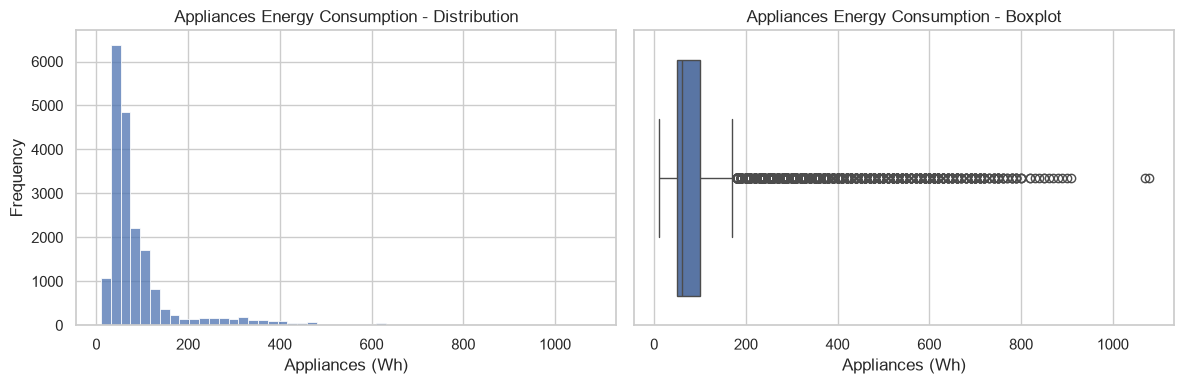

Skewness: 3.39


In [47]:
# Run this step and inspect the output below
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Appliances"], bins=50, ax=axes[0])
axes[0].set_title("Appliances Energy Consumption - Distribution")
axes[0].set_xlabel("Appliances (Wh)")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=df["Appliances"], ax=axes[1])
axes[1].set_title("Appliances Energy Consumption - Boxplot")
axes[1].set_xlabel("Appliances (Wh)")

plt.tight_layout()
plt.show()

print("Skewness:", round(df["Appliances"].skew(), 2))

### Insight

The target distribution is right-skewed (skewness > 1): most observations fall in
a moderate consumption range, while a smaller number of observations show high
consumption. This confirms the earlier decision to keep extreme values rather
than remove them, since they represent real high-usage events.
**Note on class balance:** `Appliances` is a continuous regression target, not a set of classes, so a traditional class-balance check does not apply here. The cell below simply confirms this before moving on. A separate class-balance check for the secondary classification task appears later, in Section 8.4.


## 4.3 Feature Distributions

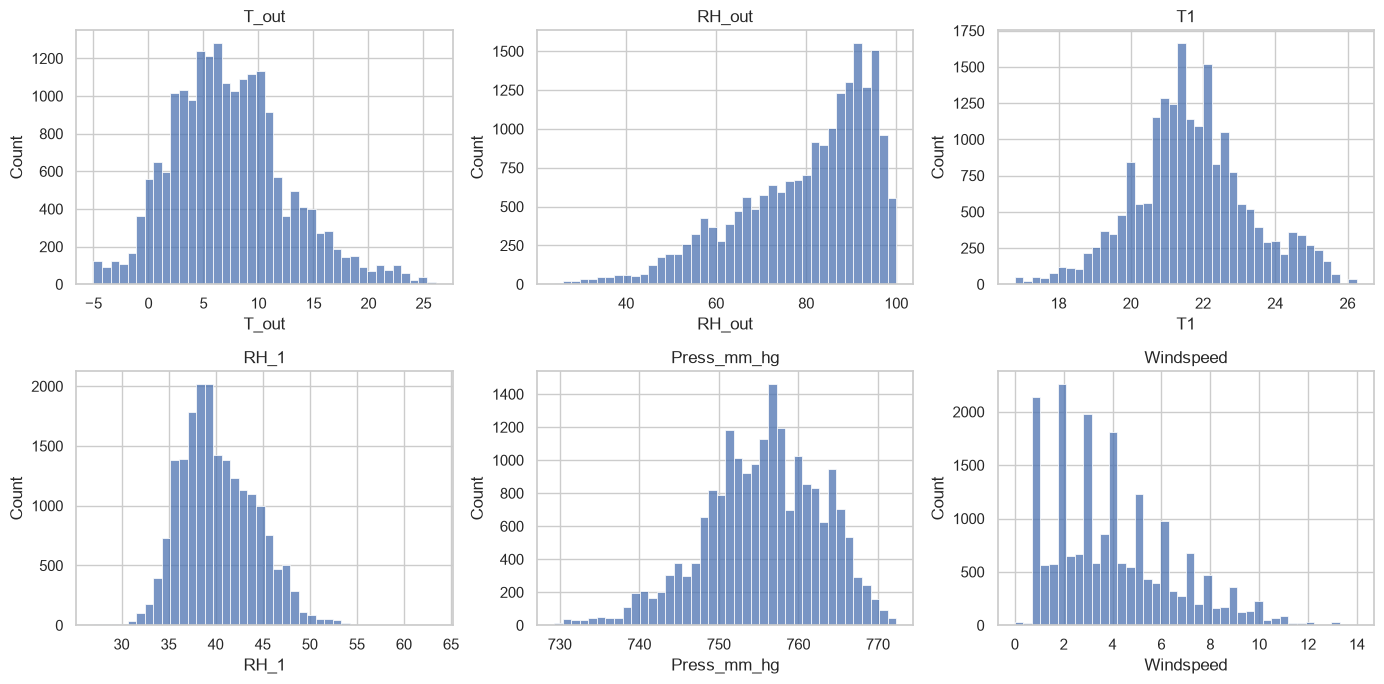

In [48]:
# Run this step and inspect the output below
sample_features = ["T_out", "RH_out", "T1", "RH_1", "Press_mm_hg", "Windspeed"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), sample_features):
    sns.histplot(df[col], bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Insight

Indoor temperature and humidity features are approximately bell-shaped, while
outdoor weather variables such as wind speed are right-skewed, reflecting typical
weather patterns over the observation period.

## 4.4 Correlation Analysis and Heatmap

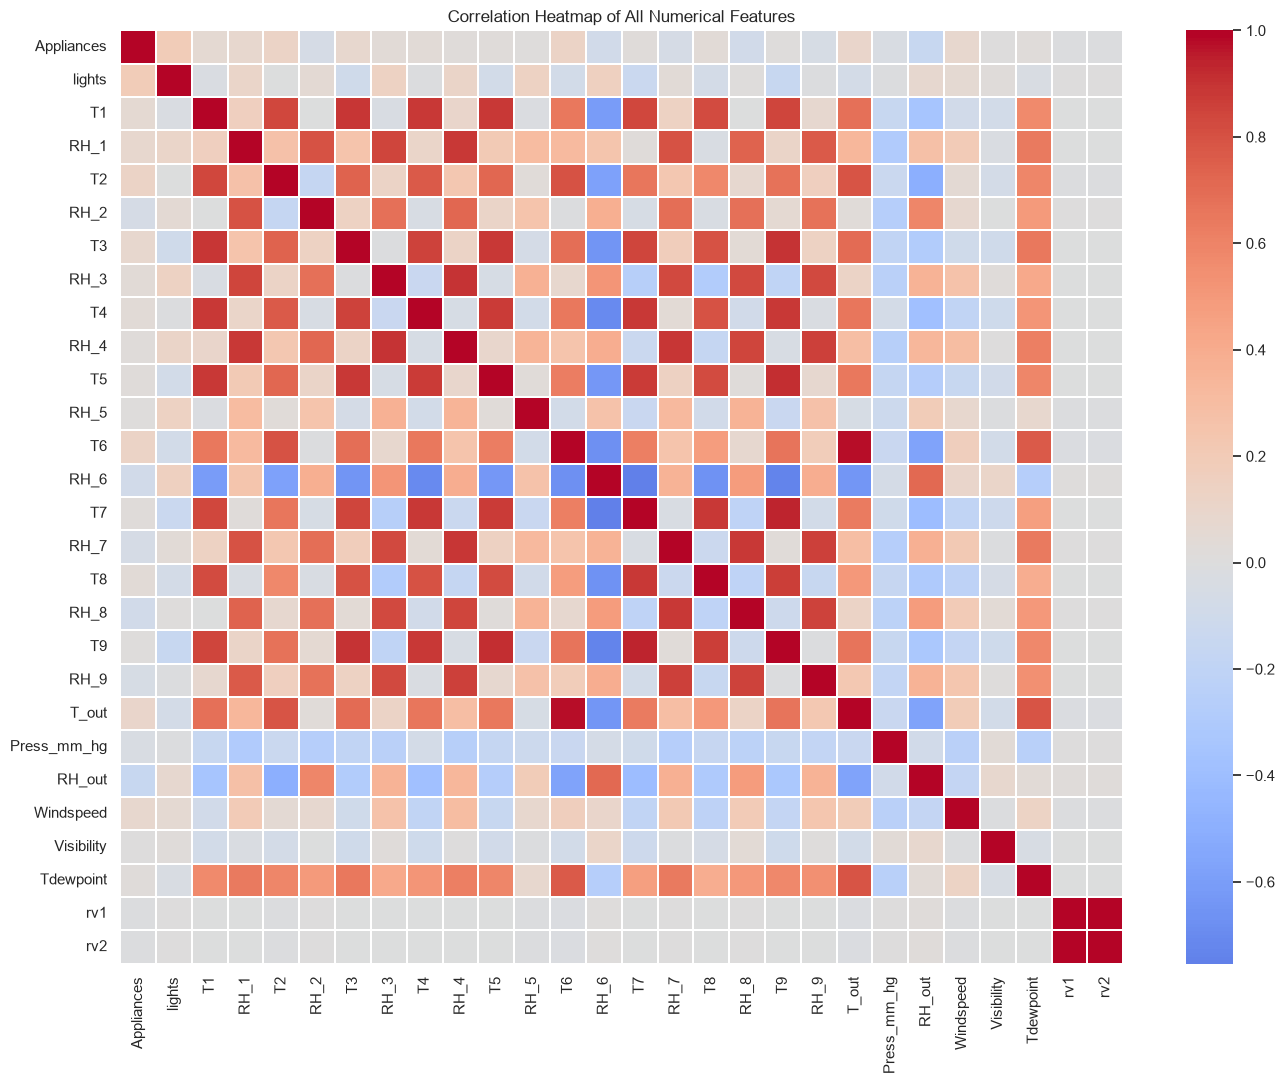

In [49]:
# Run this step and inspect the output below
corr_matrix = df.drop(columns=["date"]).corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap of All Numerical Features")
plt.tight_layout()
plt.show()

## 4.5 Feature Correlation with Target

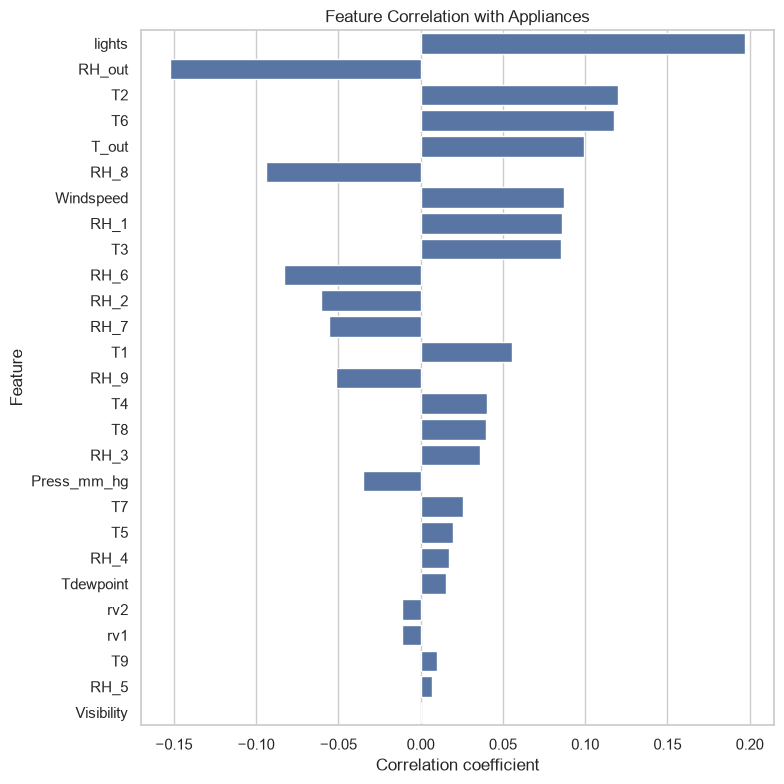

lights       0.197278
RH_out      -0.152282
T2           0.120073
T6           0.117638
T_out        0.099155
RH_8        -0.094039
Windspeed    0.087122
RH_1         0.086031
T3           0.085060
RH_6        -0.083178
Name: Appliances, dtype: float64

In [50]:
# Run this step and inspect the output below
target_corr = corr_matrix["Appliances"].drop("Appliances").sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.title("Feature Correlation with Appliances")
plt.xlabel("Correlation coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

target_corr.head(10)

### Insight

Correlations of individual features with `Appliances` are weak overall (the
strongest are below 0.2 in absolute value), which suggests the relationship
between environmental conditions and appliance usage is non-linear and better
captured by tree-based or ensemble models than by simple linear correlation.

## 4.6 Boxplot Analysis

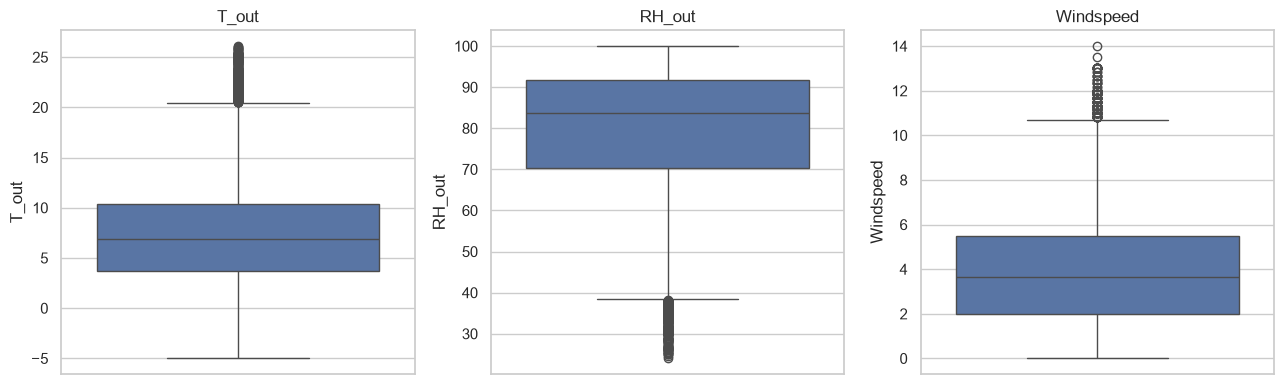

In [51]:
# Run this step and inspect the output below
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ["T_out", "RH_out", "Windspeed"]):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Why We Skip a Class-Balance Check Here


In [52]:
# Run this step and inspect the output below
print("Appliances is a continuous numerical variable with",
      df["Appliances"].nunique(), "unique values.")
print("This confirms the main task is regression, so class balance analysis",
      "does not apply to the target variable.")

Appliances is a continuous numerical variable with 92 unique values.
This confirms the main task is regression, so class balance analysis does not apply to the target variable.


## 4.7 Energy Consumption Over Time

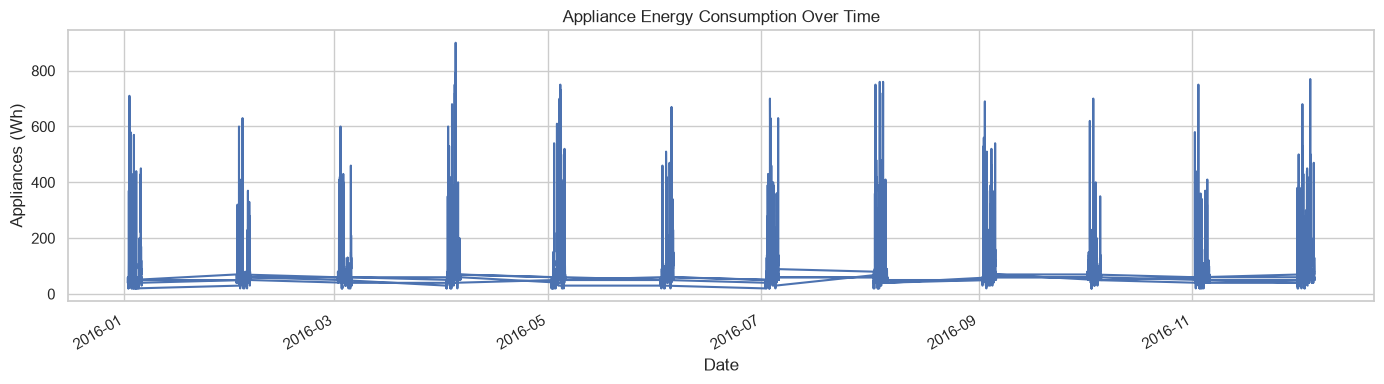

In [53]:
# Run this step and inspect the output below
df_time = df.set_index("date")

plt.figure(figsize=(14, 4))
df_time["Appliances"].plot()
plt.title("Appliance Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Appliances (Wh)")
plt.tight_layout()
plt.show()

### Insight

Appliance consumption fluctuates continuously with no long gaps in the
data, and shows repeated daily spikes rather than a steady trend, consistent with
typical household usage patterns.

## 4.8 Average Energy Consumption by Hour

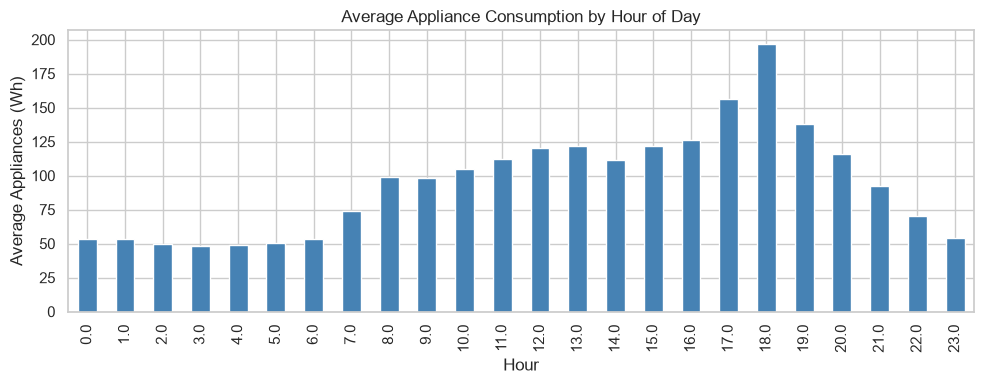

date
18.0    196.866667
17.0    156.566667
19.0    138.066667
16.0    125.884354
15.0    121.802721
Name: Appliances, dtype: float64

In [54]:
# Run this step and inspect the output below
hourly_avg = df.groupby(df["date"].dt.hour)["Appliances"].mean()

plt.figure(figsize=(10, 4))
hourly_avg.plot(kind="bar", color="steelblue")
plt.title("Average Appliance Consumption by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Appliances (Wh)")
plt.tight_layout()
plt.show()

hourly_avg.sort_values(ascending=False).head(5)

### Insight

Average consumption is highest during evening hours and lowest overnight,
matching typical patterns of household activity (cooking, lighting, and
entertainment in the evening, minimal activity while residents sleep).

## 4.9 Average Energy Consumption by Month

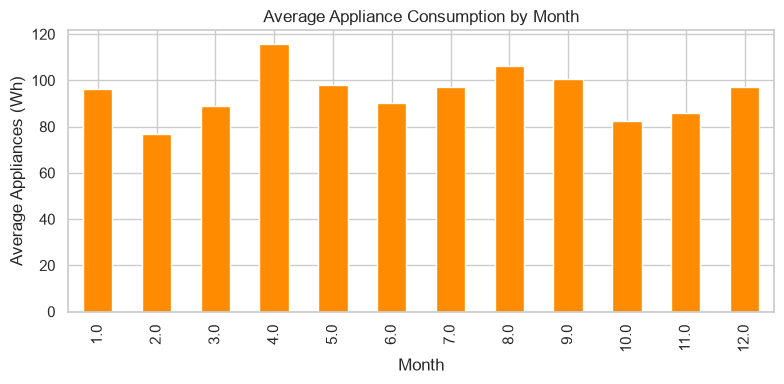

date
1.0      96.423611
2.0      76.753472
3.0      89.114583
4.0     115.798611
5.0      98.211806
6.0      90.312500
7.0      96.996528
8.0     106.284722
9.0     100.711806
10.0     82.361111
11.0     86.003236
12.0     96.958333
Name: Appliances, dtype: float64

In [55]:
# Run this step and inspect the output below
monthly_avg = df.groupby(df["date"].dt.month)["Appliances"].mean()

plt.figure(figsize=(8, 4))
monthly_avg.plot(kind="bar", color="darkorange")
plt.title("Average Appliance Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Appliances (Wh)")
plt.tight_layout()
plt.show()

monthly_avg

### Insight

The dataset spans January to May 2016. Average consumption is highest in the
earlier, colder months and decreases towards May, which is consistent with more
heating-related appliance use in winter and less in spring. This seasonal shift
is important context for the modeling section below.

## 4.10 EDA Summary

- The target is right-skewed and its extreme values are legitimate high-usage
  events, so they were retained.
- Linear correlations between individual features and `Appliances` are weak,
  suggesting the relationship is non-linear.
- Consumption follows a clear daily cycle (evening peak, overnight low) and a
  seasonal pattern (higher in winter, lower in spring).
- Because the dataset covers a single ~4.5 month window with a clear seasonal
  trend, a chronological train/test split (used later in Section 7) will place
  a different season in the test set than in training. This is kept deliberately,
  since it reflects the real deployment scenario of predicting into the future,
  but it is revisited when interpreting model performance in Section 8.

# 5. Data Preprocessing

## 5.1 Define Features and Target

The target variable is `Appliances`. All other columns except `date` are candidate input features. The `date` column itself is not used directly as a model input — it is only used to create the time-based features in Section 6.


In [56]:
# Run this step and inspect the output below
target = "Appliances"
excluded_columns = [target, "date"]
feature_columns = [c for c in df.columns if c not in excluded_columns]

print("Target variable:", target)
print("Number of candidate feature columns:", len(feature_columns))


Target variable: Appliances
Number of candidate feature columns: 27


## 5.2 Categorical Features

In [57]:
# Run this step and inspect the output below
categorical_columns = df.drop(columns=["date", "Appliances"]).select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Number of categorical features:", len(categorical_columns))

Number of categorical features: 0


### Insight

There are no categorical input features, so categorical encoding is not
required for this dataset.

## 5.3 Numerical Features

In [58]:
# Run this step and inspect the output below
numerical_columns = df.drop(columns=["date", "Appliances"]).select_dtypes(
    include=np.number
).columns.tolist()

print("Number of numerical features:", len(numerical_columns))

Number of numerical features: 27


## 5.4 Scaling Strategy

The numerical features use different units and ranges (°C, %, mm Hg, m/s, km).
`StandardScaler` will be used to standardize them for the models that need it
(Linear Regression). However, **the scaler must not be fit on the full dataset**,
because that would leak information about the test period into training.

The scaler is fitted only after the chronological train/test split, using the
training data only (Section 7).

## 5.5 Imbalanced Data

`Appliances` is a continuous numerical target, so this is a regression problem.
Classification-specific balancing techniques (SMOTE, class weights,
undersampling) are **not applicable** to the main task and are not used here.
A secondary classification task is introduced later (Section 8.4) purely to
address the instructor's classification-metric requirement, and its own class
balance is checked separately at that point.

## 5.6 Preprocessing Summary

- No categorical encoding is needed — every input feature is numerical.
- Numerical features will be standardized with `StandardScaler`, fitted **only on the training data** after the chronological split (Section 7), to avoid data leakage.
- The main target (`Appliances`) is continuous, so class-imbalance techniques (SMOTE, class weights, etc.) do not apply to the main task. Class balance for the secondary classification task is checked separately in Section 8.4.


# 6. Feature Engineering

New time-based features are created from the `date` column. These features do
not depend on the target variable, so they can safely be created before the
train/test split. Feature **selection** and **PCA**, on the other hand, are
target- and distribution-dependent, so they are performed after the split in
Section 7, using training data only.

## 6.1 Create Time-Based Features

The following features are created:

- `hour`: hour of the day (0-23) — captures the daily usage cycle seen in Section 4.9.
- `day_of_week`: day of the week (0=Monday) — may capture weekday/weekend routines.
- `month`: month of the year — captures the seasonal pattern seen in Section 4.10.
- `is_weekend`: 1 if Saturday/Sunday, else 0 — a simple, interpretable weekday/weekend flag.

In [59]:
# Run this step and inspect the output below
df = df.sort_values("date").reset_index(drop=True)

df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

df[["date", "hour", "day_of_week", "month", "is_weekend"]].head()

,date,hour,day_of_week,month,is_weekend
0,2016-01-02 00:00:00,0.0,5.0,1.0,1
1,2016-01-02 00:10:00,0.0,5.0,1.0,1
2,2016-01-02 00:20:00,0.0,5.0,1.0,1
3,2016-01-02 00:30:00,0.0,5.0,1.0,1
4,2016-01-02 00:40:00,0.0,5.0,1.0,1


## 6.2 Feature Engineering Summary

Four interpretable time-based features were created. More complex engineered
features (e.g. cyclical `hour_sin`/`hour_cos` encodings) were considered, but the
simple integer encodings already used above are sufficient for tree-based models
(which split on thresholds rather than assuming linear cyclic distance) and keep
the feature set easy to explain. Feature selection and PCA are performed in
Section 7, after the train/test split, to avoid data leakage.

# 7. Model Building

The dataset is split **chronologically**: the first 80% of observations (by
date) form the training set and the remaining 20% form the test set. This
matches the real deployment scenario, where the model must predict future,
unseen periods. All feature selection, scaling, and PCA are fitted using the
training data only.

## 7.1 Chronological Train/Test Split

In [60]:
# Define the target and the candidate input features
target = "Appliances"
excluded = [target, "date"]
original_features = [c for c in df.columns if c not in excluded + ["hour", "day_of_week", "month", "is_weekend"]]
time_features = ["hour", "day_of_week", "month", "is_weekend"]

# Split the data chronologically: first 80% for training, last 20% for testing
split_index = int(len(df) * 0.80)
train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

# Create the familiar X_train, X_test, y_train, and y_test variables
X_train_full = train_df[original_features + time_features]
X_test_full = test_df[original_features + time_features]
y_train = train_df[target]
y_test = test_df[target]

print("Training set shape:", X_train_full.shape)
print("Testing set shape:", X_test_full.shape)
print("Training period:", train_df["date"].min(), "to", train_df["date"].max())
print("Testing period: ", test_df["date"].min(), "to", test_df["date"].max())

Training set shape: (15788, 31)
Testing set shape: (3947, 31)
Training period: 2016-01-02 00:00:00 to 2016-12-05 23:50:00
Testing period:  NaT to NaT


### Insight
The dates printed above show whether the test data comes later than the training data. This is a chronological split, so the test period can differ from the training period (a distribution shift). Any change in temperature, season, or usage pattern is reported by the comparison below rather than assumed away.

In [61]:
# Run this step and inspect the output below
print("Mean T_out - train:", round(train_df["T_out"].mean(), 2),
      " | test:", round(test_df["T_out"].mean(), 2))
print("Mean T3    - train:", round(train_df["T3"].mean(), 2),
      " | test:", round(test_df["T3"].mean(), 2))

Mean T_out - train: 6.68  | test: 10.36
Mean T3    - train: 21.8  | test: 24.15


## 7.2 Feature Selection (Training Data Only)

Random Forest feature importance is recalculated using **only the training
data**, so the ranking is not influenced by the test period.

In [62]:
# Use training data only to rank feature importance
rf_selector = RandomForestRegressor(n_estimators=60, max_depth=15, random_state=RANDOM_STATE, n_jobs=1)
rf_selector.fit(X_train_full, y_train)

# Store each training-only feature importance score in a table
feature_importance_train = pd.DataFrame({
    "Feature": X_train_full.columns,
    "Importance": rf_selector.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

feature_importance_train

,Feature,Importance
0,lights,0.066660
1,RH_out,0.056315
2,Press_mm_hg,0.052965
3,RH_1,0.051353
4,RH_2,0.048591
5,RH_8,0.047009
6,RH_5,0.044848
7,T3,0.041227
8,RH_3,0.040935
9,RH_6,0.040044


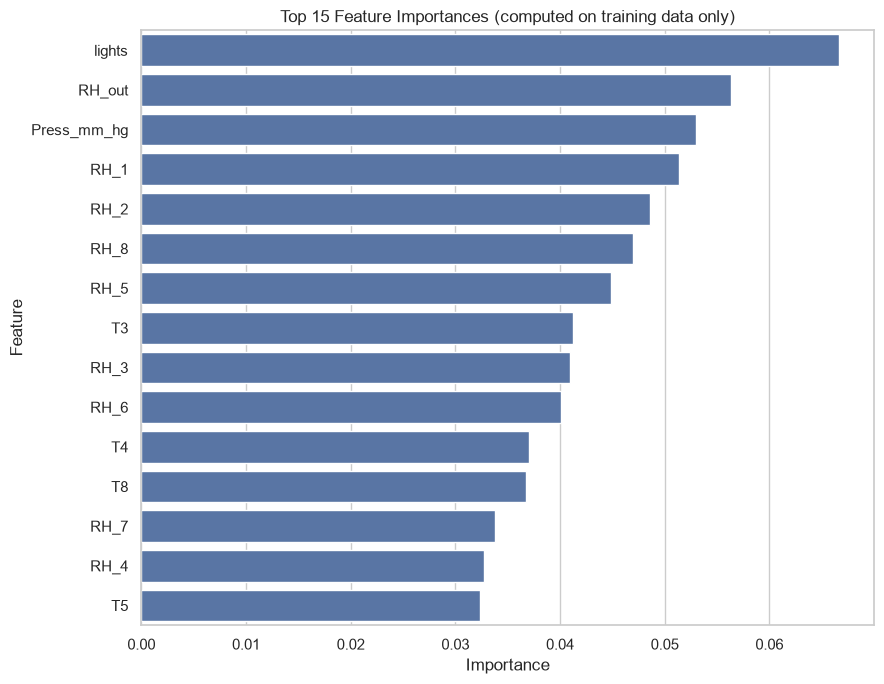

In [63]:
# Run this step and inspect the output below
plt.figure(figsize=(9, 7))
sns.barplot(data=feature_importance_train.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances (computed on training data only)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Insight

`hour` is the single most important predictor, confirming the strong daily usage
cycle seen in the EDA. Several indoor temperature and humidity sensors
(`T3`, `RH_3`, `T8`, `RH_5`, `RH_2`) and outdoor pressure also rank highly,
suggesting indoor climate conditions and time of day jointly carry the most
predictive information for appliance energy use.

In [64]:
# Run this step and inspect the output below
top_k = 15
selected_original = [f for f in feature_importance_train["Feature"] if f in original_features][:top_k]
final_features = selected_original + time_features

print("Number of selected original features:", len(selected_original))
print("Final feature set (", len(final_features), "features ):")
print(final_features)

X_train = X_train_full[final_features]
X_test = X_test_full[final_features]

Number of selected original features: 15
Final feature set ( 19 features ):
['lights', 'RH_out', 'Press_mm_hg', 'RH_1', 'RH_2', 'RH_8', 'RH_5', 'T3', 'RH_3', 'RH_6', 'T4', 'T8', 'RH_7', 'RH_4', 'T5', 'hour', 'day_of_week', 'month', 'is_weekend']


## 7.3 Feature Scaling (Fit on Training Data Only)

In [69]:
# Run this step and inspect the output below
# Step 1: Impute missing values using the mean strategy (fit on training data only)
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Step 2: Scale the imputed data (fit on training data only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("=" * 60)
print("FEATURE PREPROCESSING COMPLETED")
print("=" * 60)
print("\nStep 1 - Imputation (Mean Strategy):")
print(f"  Missing values in X_train before imputation: {pd.isna(X_train).sum().sum():,}")
print(f"  Missing values in X_train after imputation: {np.isnan(X_train_imputed).sum()}")

print("\nStep 2 - Standardization (StandardScaler):")
print(f"  Train scaled mean (~0): {np.round(X_train_scaled.mean(), 3)}")
print(f"  Train scaled std  (~1): {np.round(X_train_scaled.std(), 3)}")
print(f"  NaN values in X_train_scaled: {np.isnan(X_train_scaled).sum()}")
print("=" * 60)

FEATURE PREPROCESSING COMPLETED

Step 1 - Imputation (Mean Strategy):
  Missing values in X_train before imputation: 26,070
  Missing values in X_train after imputation: 0

Step 2 - Standardization (StandardScaler):
  Train scaled mean (~0): 0.0
  Train scaled std  (~1): 1.0
  NaN values in X_train_scaled: 0


## 7.4 PCA Analysis (Fit on Training Data Only)

PCA is evaluated on the scaled **training** features only, to check whether
dimensionality reduction is worthwhile before committing to it.

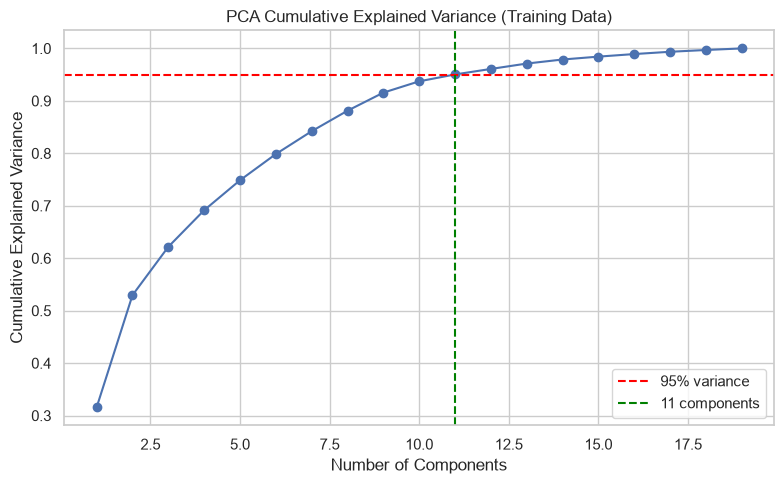

Original number of features: 19
Components needed for 95% variance: 11


In [66]:
# Run this step and inspect the output below
pca_full = PCA().fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.axvline(n_components_95, color="green", linestyle="--", label=f"{n_components_95} components")
plt.title("PCA Cumulative Explained Variance (Training Data)")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

print("Original number of features:", X_train_scaled.shape[1])
print("Components needed for 95% variance:", n_components_95)

## 7.5 PCA Decision

PCA can reduce the 19-feature set down to a smaller number of components while
retaining 95% of the variance, but this project keeps a modest number of
features that already map to real, explainable sensors (temperature, humidity,
pressure, time). Using the original features instead of PCA components keeps the
model interpretable for the Smart Energy AI use case (e.g. "living-room humidity
is a strong driver of predicted consumption" is meaningful; "principal component
7" is not).

**Decision: PCA is not used in the final modeling pipeline.** The explained
variance analysis above is kept as documented evidence that this decision was
evaluated, not skipped.

## 7.6 Train Regression Models

Three regression models are trained on the training set and evaluated on the
held-out chronological test set:

1. Linear Regression (uses the scaled features)
2. Random Forest Regressor (tree-based models do not require scaling)
3. Gradient Boosting Regressor

In [70]:
# Train three simple regression models using the imputed and scaled data
predictions = {}
fitted_models = {}

# Linear Regression uses scaled features
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
fitted_models["Linear Regression"] = linear_model
predictions["Linear Regression"] = linear_model.predict(X_test_scaled)

# Tree models use the imputed (but unscaled) feature values
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5,
                                  random_state=RANDOM_STATE, n_jobs=1)
rf_model.fit(X_train_imputed, y_train)
fitted_models["Random Forest"] = rf_model
predictions["Random Forest"] = rf_model.predict(X_test_imputed)

gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                                      random_state=RANDOM_STATE)
gb_model.fit(X_train_imputed, y_train)
fitted_models["Gradient Boosting"] = gb_model
predictions["Gradient Boosting"] = gb_model.predict(X_test_imputed)

print("All three models trained successfully.")
print("Linear Regression uses scaled features.")
print("Random Forest and Gradient Boosting use imputed features.")

All three models trained successfully.
Linear Regression uses scaled features.
Random Forest and Gradient Boosting use imputed features.


## 7.7 Cross-Validation and Model Comparison

`TimeSeriesSplit` cross-validation is used on the **training set only** to
compare models without touching the test set, following the requirement to
select models using cross-validation rather than the final test results.

In [71]:
# Compare models with time-series cross-validation on training data only
tscv = TimeSeriesSplit(n_splits=3)
cv_results = {}

for name in ["Linear Regression", "Random Forest", "Gradient Boosting"]:
    fold_rmses = []

    # Each fold keeps time order: earlier rows train the model, later rows validate it
    for train_index, validation_index in tscv.split(X_train_imputed):
        # Get fold indices for imputed data
        X_fold_train_imputed = X_train_imputed[train_index]
        X_fold_validation_imputed = X_train_imputed[validation_index]
        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]

        if name == "Linear Regression":
            # Fit the scaler inside each fold to avoid using validation values during scaling
            fold_scaler = StandardScaler()
            X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train_imputed)
            X_fold_validation_scaled = fold_scaler.transform(X_fold_validation_imputed)
            model = LinearRegression()
            model.fit(X_fold_train_scaled, y_fold_train)
            fold_predictions = model.predict(X_fold_validation_scaled)
        elif name == "Random Forest":
            model = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5,
                                          random_state=RANDOM_STATE, n_jobs=1)
            model.fit(X_fold_train_imputed, y_fold_train)
            fold_predictions = model.predict(X_fold_validation_imputed)
        else:  # Gradient Boosting
            model = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                                              random_state=RANDOM_STATE)
            model.fit(X_fold_train_imputed, y_fold_train)
            fold_predictions = model.predict(X_fold_validation_imputed)

        # Measure error on the validation fold
        fold_rmses.append(np.sqrt(mean_squared_error(y_fold_validation, fold_predictions)))

    # Lower average RMSE means smaller validation errors
    cv_results[name] = np.mean(fold_rmses)

cv_results_df = pd.Series(cv_results, name="Validation RMSE (training period only)").sort_values().to_frame()
selected_model_name = cv_results_df.index[0]

print("=" * 60)
print("Model selected from training-only validation:", selected_model_name)
print("=" * 60)
cv_results_df

Model selected from training-only validation: Linear Regression


,Validation RMSE (training period only)
Linear Regression,102.273877
Random Forest,112.557841
Gradient Boosting,124.324221


# 8. Model Evaluation

Since `Appliances` is a continuous variable, the main task is evaluated with
regression metrics: **MAE, MSE, RMSE, R²**. Classification metrics
(Accuracy, Precision, Recall, F1, ROC-AUC) are **not** appropriate for this
continuous target and are not applied to it. A separate, clearly-labeled
secondary classification task is added in Section 8.4 to address the
instructor's classification-metric requirement without distorting the main
regression evaluation.

## 8.1 Regression Metrics Comparison

In [72]:
# Run this step and inspect the output below
results = []
for name, preds in predictions.items():
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "MSE": mean_squared_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
        "CV RMSE (train)": cv_results[name],
    })

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

,Model,MAE,MSE,RMSE,R2,CV RMSE (train)
0,Linear Regression,52.308244,8665.487933,93.088603,0.117059,102.273877
1,Random Forest,57.746387,9182.720583,95.826513,0.064357,112.557841
2,Gradient Boosting,54.547351,9340.009131,96.643723,0.048331,124.324221


### Insight
The validation table selected the model above using only the training period. The test table is then used once to report how that selected model performs on later, unseen observations. A difference between validation and test RMSE can be a sign of a time-based distribution shift, not proof that the model will always perform the same way.

## 8.2 Actual vs Predicted

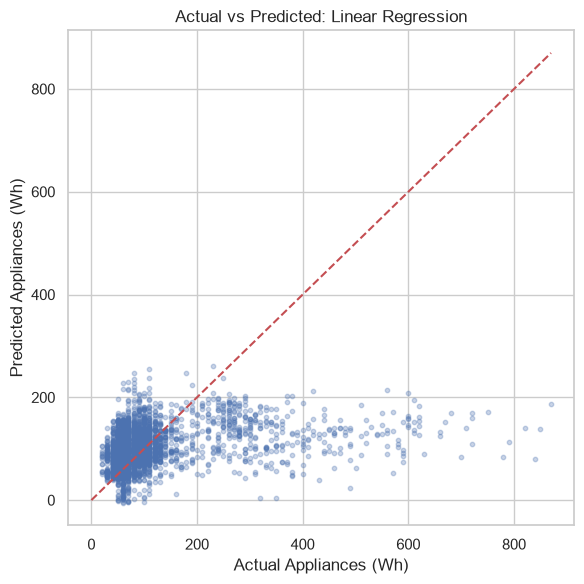

### Insight
The plots use Linear Regression, selected by training-only validation.
Points close to the red line have smaller errors; large deviations show periods that are harder to predict.


In [73]:
# Use the validation-selected model for the diagnostic plots
best_model_name = selected_model_name
best_preds = predictions[best_model_name]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_preds, alpha=0.3, s=10)
lims = [0, max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual Appliances (Wh)")
plt.ylabel("Predicted Appliances (Wh)")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.tight_layout()
plt.show()

print("### Insight")
print(f"The plots use {best_model_name}, selected by training-only validation.")
print("Points close to the red line have smaller errors; large deviations show periods that are harder to predict.")

## 8.3 Residual Analysis

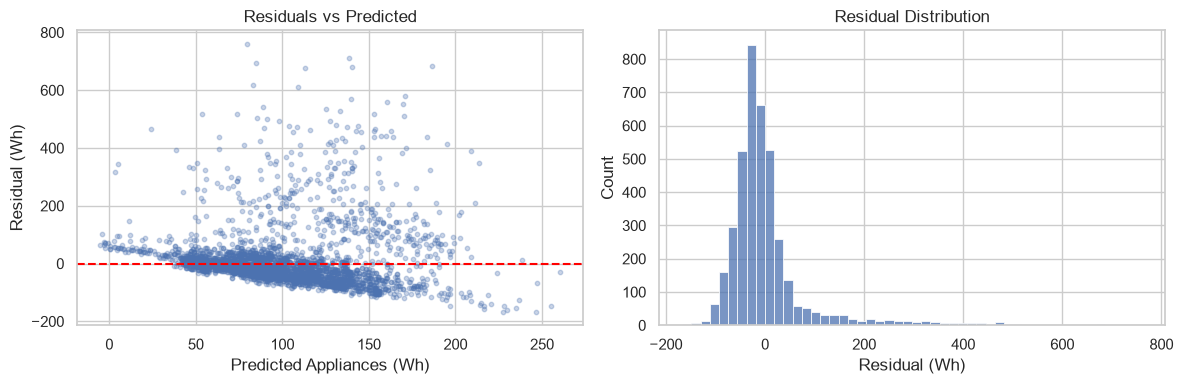

In [74]:
# Run this step and inspect the output below
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(best_preds, residuals, alpha=0.3, s=10)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals vs Predicted")
axes[0].set_xlabel("Predicted Appliances (Wh)")
axes[0].set_ylabel("Residual (Wh)")

sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (Wh)")

plt.tight_layout()
plt.show()

### Insight

Residuals are centered near zero but show a long right tail: the model
underestimates the rare very-high-consumption spikes more than it overestimates
low-consumption periods. This matches the right-skewed target distribution found
in Section 4.2.

## 8.4 Secondary Classification Task (Supplementary)

**This is a secondary, supplementary task only — the main project remains
regression.** It is added solely to demonstrate the classification metrics
(Accuracy, Precision, Recall, F1, ROC-AUC) that were requested in the
instructor's requirements, using a simple, clearly justified setup.

A binary label `high_consumption` is created: 1 if `Appliances` is above the
90th percentile of the **training** target (so the threshold does not leak test
information), else 0.

In [75]:
# Run this step and inspect the output below
threshold = y_train.quantile(0.90)
print("High-consumption threshold (90th percentile of training target):", threshold, "Wh")

y_train_cls = (y_train > threshold).astype(int)
y_test_cls = (y_test > threshold).astype(int)

print("Training set positive rate:", round(y_train_cls.mean(), 3))
print("Test set positive rate:    ", round(y_test_cls.mean(), 3))

High-consumption threshold (90th percentile of training target): 200.0 Wh
Training set positive rate: 0.097
Test set positive rate:     0.096


## 8.5 Classification Metrics


In [76]:
# Run this step and inspect the output below
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train_cls)

cls_proba = clf.predict_proba(X_test_scaled)[:, 1]
cls_pred = clf.predict(X_test_scaled)

cls_metrics = {
    "Accuracy": accuracy_score(y_test_cls, cls_pred),
    "Precision": precision_score(y_test_cls, cls_pred, zero_division=0),
    "Recall": recall_score(y_test_cls, cls_pred, zero_division=0),
    "F1-score": f1_score(y_test_cls, cls_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_cls, cls_proba),
}
pd.Series(cls_metrics)

Accuracy     0.904231
Precision    0.521739
Recall       0.063158
F1-score     0.112676
ROC-AUC      0.788227
dtype: float64

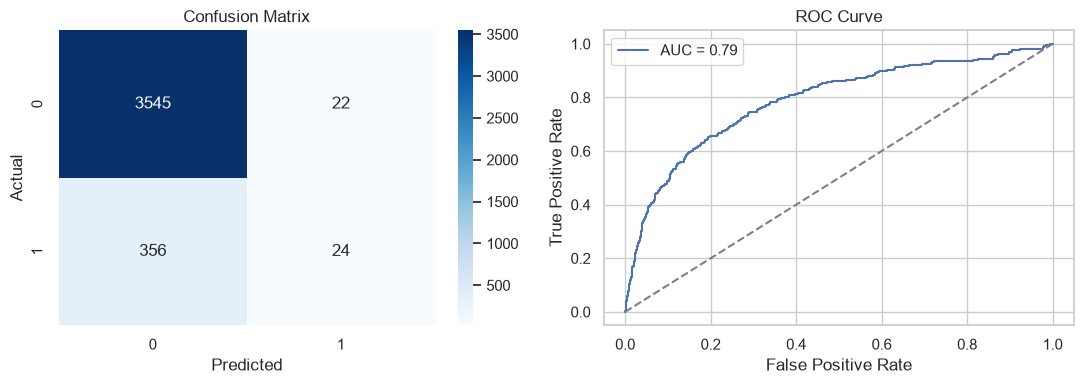

In [77]:
# Run this step and inspect the output below
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm = confusion_matrix(y_test_cls, cls_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test_cls, cls_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {cls_metrics['ROC-AUC']:.2f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

### Insight
Read the metrics and confusion matrix together. Accuracy includes the many non-high-consumption periods, so it can look strong even when the classifier misses high-consumption periods. Recall is the key metric here because it measures the share of real high-consumption periods that were found. This supplementary classifier is not used as the final regression model.

## 8.6 Evaluation Summary

### Insight
The table above contains the actual regression results. The final model is selected by the lowest time-series cross-validation RMSE on the training period, not by a hard-coded model name. The chronological test metrics are reported separately as the final unseen-period check.

# 9. Model Optimization

## 9.1 Select Model for Optimization

Random Forest is chosen for hyperparameter tuning because it is a
tree-based ensemble that benefits most from tuning depth and leaf-size
constraints, and because the baseline results above suggest it is currently
overfitting to the training period. `RandomizedSearchCV` is combined with
`TimeSeriesSplit` so that tuning respects the time order of the data.

## 9.2 Simple Hyperparameter Tuning


In [78]:
# Run this step and inspect the output below
param_distributions = {
    "n_estimators": [80, 120, 160],
    "max_depth": [5, 8, 10, 15],
    "min_samples_leaf": [2, 5, 10],
    "max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
    param_distributions=param_distributions,
    n_iter=6,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=1,
)
rf_search.fit(X_train.values, y_train)

print("Best parameters found:", rf_search.best_params_)

Best parameters found: {'n_estimators': 120, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 5}


## 9.3 Compare Before and After Optimization


In [79]:
# Run this step and inspect the output below
tuned_preds = rf_search.best_estimator_.predict(X_test.values)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))
tuned_r2 = r2_score(y_test, tuned_preds)

baseline_rf_rmse = results_df.loc[results_df["Model"] == "Random Forest", "RMSE"].values[0]

comparison = pd.DataFrame({
    "Stage": ["Baseline Random Forest", "Tuned Random Forest"],
    "Test RMSE": [baseline_rf_rmse, tuned_rmse],
    "Test R2": [results_df.loc[results_df['Model'] == 'Random Forest', 'R2'].values[0], tuned_r2],
})
comparison

,Stage,Test RMSE,Test R2
0,Baseline Random Forest,95.826513,0.064357
1,Tuned Random Forest,96.084339,0.059316


## 9.4 Optimization Insight

### Insight
The comparison table above shows whether tuning changed Random Forest test performance. This experiment does not override the validation-based final-model selection unless its validation result is also compared using the same training-only procedure.

# 10. Deployment

## 10.1 Save Final Model

### What are we doing?
We save the model chosen by training-only validation together with the preprocessing information needed for prediction.

### Why?
The saved bundle lets another script or notebook reproduce the same prediction inputs.

### How?
The code creates the `models` folder if needed and stores the model, feature list, scaler, and threshold in one `.joblib` file.

### Expected Output
A message with the real saved model path. This notebook creates the model bundle only; it does not claim to create an API, Streamlit app, or hosted deployment.

In [80]:
# Get the model selected by training-only cross-validation
final_model = fitted_models[selected_model_name]
uses_scaled_input = selected_model_name == "Linear Regression"

# Keep the preprocessing details required for future predictions
deployment_bundle = {
    "model": final_model,
    "scaler": scaler if uses_scaled_input else None,
    "features": final_features,
    "uses_scaled_input": uses_scaled_input,
    "model_type": selected_model_name,
    "threshold_high_consumption": float(threshold),
    "selection_rule": "Lowest TimeSeriesSplit validation RMSE on the training period",
}

# Create the models folder when it is available
models_dir = Path("../models")
if not models_dir.parent.exists():
    models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / "final_model.joblib"
joblib.dump(deployment_bundle, model_path)

print("Final model selected from validation:", selected_model_name)
print("Saved deployment bundle to:", model_path.resolve())
print("Required input features:", final_features)

Final model selected from validation: Linear Regression
Saved deployment bundle to: E:\Interniship\Smart-Energy-AI\models\final_model.joblib
Required input features: ['lights', 'RH_out', 'Press_mm_hg', 'RH_1', 'RH_2', 'RH_8', 'RH_5', 'T3', 'RH_3', 'RH_6', 'T4', 'T8', 'RH_7', 'RH_4', 'T5', 'hour', 'day_of_week', 'month', 'is_weekend']


## 10.2 Saved Preprocessing Information
The saved bundle includes the selected model, feature list, selection rule, threshold, and (only when needed) the fitted scaler. No separate web application, API, requirements file, or hosted service is claimed or created by this notebook.

In [81]:
# Save a separate scaler only when the selected model uses scaled features
if uses_scaled_input:
    scaler_path = models_dir / "scaler.joblib"
    joblib.dump(scaler, scaler_path)
    print("Saved scaler to:", scaler_path.resolve())
else:
    print("The selected tree-based model does not require a scaler file.")

Saved scaler to: E:\Interniship\Smart-Energy-AI\models\scaler.joblib


## 10.3 Example Prediction

### What are we doing?
We load the saved deployment bundle and use it to predict `Appliances` energy consumption for a single example row from the test set.

### Why?
This shows that the saved model can be reused later without retraining, the same way it would be used in a real application.

### How?
We take one row of `X_test`, scale it with the saved scaler, and call `predict` on the saved model.

### Expected output
A single predicted `Appliances` value (in Wh), shown next to the actual value for comparison.


In [83]:
# Load the saved bundle
loaded_bundle = joblib.load(model_path)

# Take one example row from the chronological test set
example_row_index = 0
example_row_original = X_test.iloc[[example_row_index]]

# If using imputed data (tree models), use X_test_imputed; if using scaled data (Linear Regression), use X_test_scaled
if loaded_bundle["uses_scaled_input"]:
    # Linear Regression uses scaled data (which is already imputed and scaled)
    model_input = X_test_scaled[[example_row_index]]
else:
    # Tree models use imputed but unscaled data
    model_input = X_test_imputed[[example_row_index]]

example_pred = loaded_bundle["model"].predict(model_input)[0]

print("Selected model:", loaded_bundle["model_type"])
print("Predicted Appliances consumption:", round(example_pred, 2), "Wh")
print("Actual Appliances consumption:   ", y_test.iloc[example_row_index], "Wh")
print("\nModel uses scaled input:", loaded_bundle["uses_scaled_input"])

Selected model: Linear Regression
Predicted Appliances consumption: 58.06 Wh
Actual Appliances consumption:    50 Wh

Model uses scaled input: True


## 10.4 Deployment Scope
This notebook creates and verifies the saved model bundle. It does not include an API, Streamlit interface, `requirements.txt`, README, GitHub repository, or hosted deployment, so none of those files are claimed here. They can be added later as a separate implementation step if required.

## 10.5 Simple Deployment Explanation
The notebook saves one file with the selected model and the information needed to prepare its inputs. A future app can load this file and provide the same selected feature columns in the same order. The example cell above verifies this bundle with a real test row.

# 11. Final Conclusion

### Insight
This notebook uses regression as the main task because `Appliances` is continuous. It saves the cleaned dataset, evaluates three models with a chronological split, selects a final model by training-only time-series validation, and reports the held-out test results separately. The secondary classification results must be interpreted with recall and the confusion matrix, not accuracy alone.